## Classification Modeling

#### Imports

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, classification_report

In [2]:
df = pd.read_csv('data/master.csv')

In [3]:
df.head()

,time,title,text,upvotes,comments,sub,title_word_count,text_word_count,sentiment,title_tokens,text_tokens
0,1.686799e+09,"what exactly is mastodon, misskey, lemmy and ...",i’ve heard a lot of people talk about joining ...,0.50,0,1,10,32,0.0000,exactli mastodon misskey lemmi fedivers,heard lot peopl talk join mastodon especi also...
1,1.686799e+09,would you still feel pain when paralyzed?,if you get shot in the spine and instantly bec...,1.00,0,1,8,37,-0.7882,would still feel pain paralyz,get shot spine instantli becom paralyz neck wo...
2,1.686798e+09,someone else’s pov,i am curious on how other people experience pu...,1.00,1,1,4,55,0.9109,someon els pov,curiou peopl experi put someon els shoe actual...
3,1.686797e+09,"practically speaking, how is praxeology diffe...",whenever i read or hear that a “praxeology is ...,0.67,2,1,9,115,0.4832,practic speak praxeolog differ psycholog,whenev read hear praxeolog way deduc behavior ...
4,1.686796e+09,how does an open collector output work?,i've done some reading and it seems like essen...,0.50,2,1,8,142,0.2937,open collector output work,done read seem like essenti strang devic work ...


In [4]:
df['sub'].value_counts(normalize = True)

1    0.500608
2    0.499392
Name: sub, dtype: float64

In [5]:
df.isna().sum()

time                 0
title                0
text                 0
upvotes              0
comments             0
sub                  0
title_word_count     0
text_word_count      0
sentiment            0
title_tokens         0
text_tokens         19
dtype: int64

In [6]:
df.shape

(11516, 11)

In [7]:
df.dropna(inplace = True)

In [8]:
df.shape

(11497, 11)

In [9]:
df.isna().sum()

time                0
title               0
text                0
upvotes             0
comments            0
sub                 0
title_word_count    0
text_word_count     0
sentiment           0
title_tokens        0
text_tokens         0
dtype: int64

## Modeling with Text Tokens

In [10]:
X = df['text_tokens']
y = df['sub']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 2023)

#### Counter Vectorizer and Naive Bayes

In [11]:
pipe = Pipeline([
    ('cvec', CountVectorizer()),
    ('nb', MultinomialNB())
])

In [12]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('cvec', CountVectorizer()), ('nb', MultinomialNB())])

In [13]:
cross_val_score(pipe, X_train, y_train, cv=5).mean()

0.8010882679309997

In [14]:
pipe.score(X_train, y_train)

0.876014845743447

In [15]:
pipe.score(X_test, y_test)

0.8219130434782609

#### Counter Vectorizer and Logistic Regression (with Ridge Like Penalty)

In [16]:
pipe = Pipeline([
    ('cvec', CountVectorizer()),
    ('logr', LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000))
])

In [17]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('cvec', CountVectorizer()),
                ('logr',
                 LogisticRegression(max_iter=1000, solver='liblinear'))])

In [18]:
cross_val_score(pipe, X_train, y_train, cv=5).mean()

0.8511930461683311

In [19]:
pipe.score(X_train, y_train)

0.9690327070285316

In [20]:
pipe.score(X_test, y_test)

0.8866086956521739

#### Counter Vectorizer & Random Forrest

In [21]:
pipe = Pipeline([
    ('cvec', CountVectorizer()),
    ('rf', RandomForestClassifier())
])

In [22]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('cvec', CountVectorizer()), ('rf', RandomForestClassifier())])

In [23]:
cross_val_score(pipe, X_train, y_train, cv=5).mean()

0.8820456639429706

In [24]:
pipe.score(X_train, y_train)

0.9988401762932034

In [25]:
pipe.score(X_test, y_test)

0.8980869565217391

## Modeling with Original Text

In [26]:
X = df['text']
y = df['sub']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 2023)

#### Counter Vectorizer and Naive Bayes

In [28]:
pipe = Pipeline([
    ('cvec', CountVectorizer()),
    ('nb', MultinomialNB())
])

In [29]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('cvec', CountVectorizer()), ('nb', MultinomialNB())])

In [30]:
cross_val_score(pipe, X_train, y_train, cv=5).mean()

0.8291569992266048

In [31]:
pipe.score(X_train, y_train)

0.9008350730688935

In [32]:
pipe.score(X_test, y_test)

0.8459130434782609

In [33]:
pgrid = {
    # 'cvec__max_features': [None, 1000, 5000],
    # 'cvec__min_df': [1, 2, 3],
    'cvec__max_df': [0.4, 0.5, 0.6],
    'cvec__ngram_range': [(1, 1), (1,2)],
    # 'cvec__stop_words': [None, 'english'],
    'nb__alpha': [0.4, 0.5, 0.6],
    # 'nb__fit_prior': [True, False],
    # 'nb__class_prior': [None, [0.3, 0.7]]
}
    

In [34]:
gs = GridSearchCV(pipe, pgrid, cv = 5)

In [35]:
gs.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('cvec', CountVectorizer()),
                                       ('nb', MultinomialNB())]),
             param_grid={'cvec__max_df': [0.4, 0.5, 0.6],
                         'cvec__ngram_range': [(1, 1), (1, 2)],
                         'nb__alpha': [0.4, 0.5, 0.6]})

In [36]:
gs.score(X_train, y_train)

0.9901414984922292

In [37]:
gs.score(X_test, y_test)

0.9099130434782609

In [38]:
gs.best_params_

{'cvec__max_df': 0.5, 'cvec__ngram_range': (1, 2), 'nb__alpha': 0.5}

In [39]:
gs_nb = gs.best_estimator_

#### Counter Vectorizer and Logistic Regression (with Ridge Like Penalty)

In [76]:
pipe = Pipeline([
    ('cvec', CountVectorizer()),
    ('logr', LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000))
])

In [77]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('cvec', CountVectorizer()),
                ('logr',
                 LogisticRegression(max_iter=2000, solver='liblinear'))])

In [78]:
cross_val_score(pipe, X_train, y_train, cv=5).mean()

0.8784485692188708

In [79]:
pipe.score(X_train, y_train)

0.9834145209928091

In [80]:
pipe.score(X_test, y_test)

0.9133913043478261

In [81]:
pgrid = {
    # 'cvec__max_features': [None, 1000, 5000],
    # 'cvec__min_df': [1, 2, 3],
    'cvec__max_df': [0.3, 0.4, 0.5],
    'cvec__ngram_range': [(1, 1), (1,2), (1,3)],
    # 'cvec__stop_words': [None, 'english'],
    'logr__C': [0.5, 0.7, 1],
    'logr__solver': ['newton-cg', 'liblinear'] 
}

In [82]:
gs = GridSearchCV(pipe, pgrid, cv = 5)

In [83]:
gs.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('cvec', CountVectorizer()),
                                       ('logr',
                                        LogisticRegression(max_iter=2000,
                                                           solver='liblinear'))]),
             param_grid={'cvec__max_df': [0.3, 0.4, 0.5],
                         'cvec__ngram_range': [(1, 1), (1, 2), (1, 3), (2, 2),
                                               (2, 3), (1, 4)],
                         'logr__C': [0.5, 0.7, 1],
                         'logr__solver': ['newton-cg', 'liblinear']})

In [84]:
gs.score(X_train, y_train)

0.9989561586638831

In [85]:
gs.score(X_test, y_test)

0.9210434782608695

In [86]:
gs.best_params_

{'cvec__max_df': 0.4,
 'cvec__ngram_range': (1, 3),
 'logr__C': 1,
 'logr__solver': 'liblinear'}

In [87]:
gs_best = gs.best_estimator_

#### Counter Vectorizer & Random Forrest

In [51]:
pipe = Pipeline([
    ('cvec', CountVectorizer()),
    ('rf', RandomForestClassifier())
])

In [52]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('cvec', CountVectorizer()), ('rf', RandomForestClassifier())])

In [53]:
cross_val_score(pipe, X_train, y_train, cv=5).mean()

0.8800734389185918

In [54]:
pipe.score(X_train, y_train)

0.9990721410345628

In [55]:
pipe.score(X_test, y_test)

0.904695652173913

#### Best Grid Search Continued

In [88]:
gs_best

Pipeline(steps=[('cvec', CountVectorizer(max_df=0.4, ngram_range=(1, 3))),
                ('logr',
                 LogisticRegression(C=1, max_iter=2000, solver='liblinear'))])

In [90]:
y_preds = gs_best.predict(X_train)
y_preds_test = gs_best.predict(X_test)

In [91]:
confusion_matrix(y_train, y_preds)

array([[4291,    1],
       [   8, 4322]])

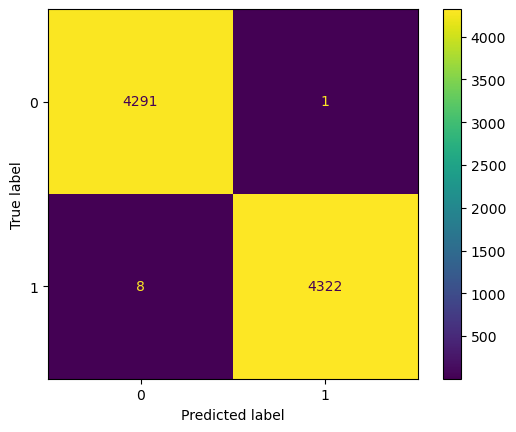

In [99]:
cm = confusion_matrix(y_train, y_preds)
cmd = ConfusionMatrixDisplay(cm)
cmd.plot();

In [101]:
confusion_matrix(y_test, y_preds_test)

array([[1366,   92],
       [ 135, 1282]])

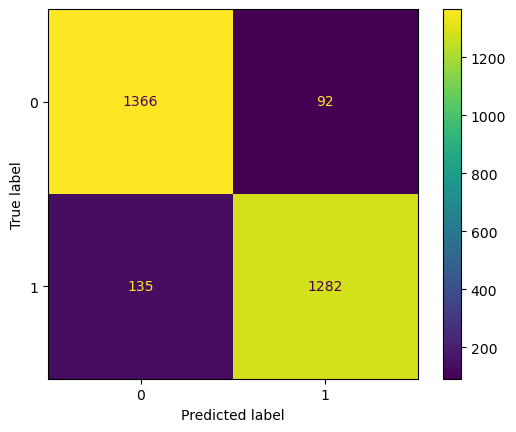

In [103]:
cm_test = confusion_matrix(y_test, y_preds_test)
cmd_test = ConfusionMatrixDisplay(cm_test)
cmd_test.plot();

In [93]:
roc_auc_score(y_train, y_preds)

0.9989597166649807

In [94]:
roc_auc_score(y_test, y_preds_test)

0.9208140810247504

In [109]:
print(classification_report(y_test, y_preds_test, digits = 5))

              precision    recall  f1-score   support

           1    0.91006   0.93690   0.92328      1458
           2    0.93304   0.90473   0.91867      1417

    accuracy                        0.92104      2875
   macro avg    0.92155   0.92081   0.92098      2875
weighted avg    0.92139   0.92104   0.92101      2875

